# Lab 06: Deriving PCA from Linear Algebra

**Reference:** Goodfellow et al. *Deep Learning*, Chapter 2, Section 2.12

This capstone lab derives PCA step by step using the linear algebra from Labs 1–5.
For a production PCA implementation, see `02-classical-ml-from-scratch/10_pca_svd.ipynb`.

Dataset shape : (300, 2)
Sample mean   : [-6.06921920e-17 -1.63572859e-16]  (should be ~0)
True cov:
[[3. 2.]
 [2. 2.]]
Sample cov:
[[3.162 1.962]
 [1.962 1.774]]


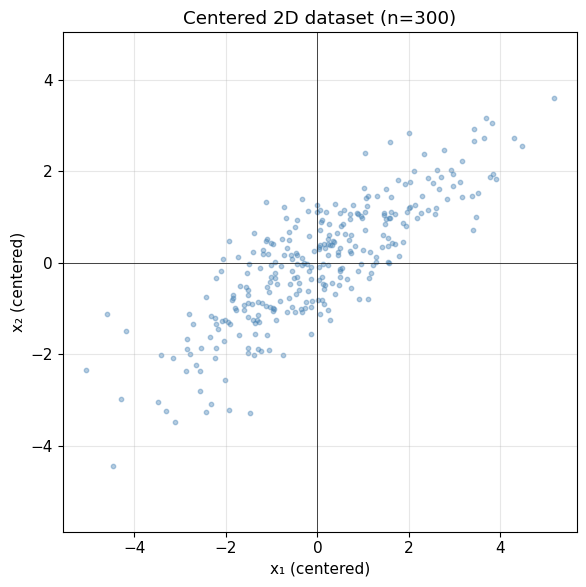

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# ── Generate 2D dataset from a multivariate Gaussian with known covariance ──
# True covariance: strong positive correlation between x1 and x2
mu_true = np.array([2.0, 3.0])
Sigma_true = np.array([[3.0, 2.0],
                        [2.0, 2.0]])

n = 300
rng = np.random.default_rng(42)
X_raw = rng.multivariate_normal(mu_true, Sigma_true, size=n)  # (300, 2)

# Center the data (subtract sample mean) — PCA always works on centered data
X_mean = X_raw.mean(axis=0)
X = X_raw - X_mean  # (300, 2), zero-mean

print(f"Dataset shape : {X.shape}")
print(f"Sample mean   : {X.mean(axis=0)}  (should be ~0)")
print(f"True cov:\n{Sigma_true}")
print(f"Sample cov:\n{np.round(X.T @ X / (n - 1), 3)}")

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.4, s=10, color='steelblue')
plt.axhline(0, color='k', lw=0.5)
plt.axvline(0, color='k', lw=0.5)
plt.xlabel('x₁ (centered)')
plt.ylabel('x₂ (centered)')
plt.title('Centered 2D dataset (n=300)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 1: The Optimization Problem

*Book reference: Section 2.12, p. 45–47*

The book formulates PCA as: find coding function **c** = f(**x**) and decoding matrix **D** such that **x** ≈ **D****c** minimizes reconstruction error.

Specifically we want to minimize $\|\mathbf{x} - \mathbf{D}\mathbf{c}\|_2^2$ subject to **D** having orthonormal columns ($\mathbf{D}^\top\mathbf{D} = \mathbf{I}_k$).

### Exercise 1 — Optimal Encoding Given D  *(basic)*

The book shows that for a fixed **D** with orthonormal columns, the optimal code is:
$$\mathbf{c}^* = \mathbf{D}^\top \mathbf{x}$$

This follows from setting the gradient of the reconstruction error to zero.

**Tasks:**
1. For a random orthonormal **D** (shape `(d, k)`, d=2, k=1), encode each data point as `c = D.T @ x`.
2. Reconstruct as `x_hat = D @ c = D @ D.T @ x`.
3. Verify the residual `(x - x_hat)` is orthogonal to every column of **D** (i.e., `D.T @ (x - x_hat) ≈ 0` for all data points).

codes shape   : (300, 1)
X_hat shape   : (300, 2)
Max |D.T @ residual| : 9.30e-16  (should be ~0)
Exercise 1: PASSED


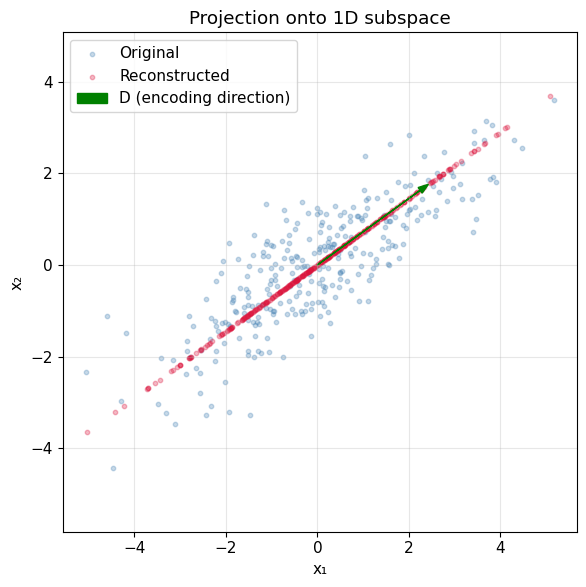

In [2]:
# Exercise 1: Optimal encoding given D
# d=2 (ambient), k=1 (code dimension)

# Build a random unit vector as our 1-component D
theta = np.pi / 5
D = np.array([[np.cos(theta)],
              [np.sin(theta)]])  # shape (2, 1) — orthonormal trivially

# (a) Encode: codes shape should be (n, k) = (300, 1)
# c = D^T @ x  for each row of X  →  X @ D gives (n, k)
codes = X @ D           # shape (300, 1)

# (b) Reconstruct: X_hat shape should be (300, 2)
# x_hat = D @ c = D @ D^T @ x  →  codes @ D.T
X_hat = codes @ D.T     # shape (300, 2)

# (c) Residuals: shape (300, 2)
residuals = X - X_hat   # shape (300, 2)


# ── Verification ──
assert codes is not None,     "codes not implemented"
assert X_hat is not None,     "X_hat not implemented"
assert residuals is not None, "residuals not implemented"
assert codes.shape == (n, 1),    f"codes shape: expected (300,1), got {codes.shape}"
assert X_hat.shape == (n, 2),    f"X_hat shape: expected (300,2), got {X_hat.shape}"
assert residuals.shape == (n, 2), f"residuals shape: expected (300,2), got {residuals.shape}"

# Orthogonality check: D.T @ residuals.T should be ~0
orthogonality = D.T @ residuals.T   # (1, 300)
assert np.allclose(orthogonality, 0, atol=1e-10), \
    f"Residuals not orthogonal to D! Max abs: {np.abs(orthogonality).max():.2e}"

print(f"codes shape   : {codes.shape}")
print(f"X_hat shape   : {X_hat.shape}")
print(f"Max |D.T @ residual| : {np.abs(orthogonality).max():.2e}  (should be ~0)")
print("Exercise 1: PASSED")

# Visualise
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, s=10, color='steelblue', label='Original')
plt.scatter(X_hat[:, 0], X_hat[:, 1], alpha=0.3, s=10, color='crimson', label='Reconstructed')
scale = 3
plt.arrow(0, 0, scale*D[0, 0], scale*D[1, 0], head_width=0.15, color='green',
          length_includes_head=True, label='D (encoding direction)')
plt.xlabel('x₁'); plt.ylabel('x₂')
plt.title('Projection onto 1D subspace')
plt.legend(); plt.axis('equal'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Exercise 2 — Sample Covariance Matrix  *(basic)*

The book (eq. 2.59) shows the optimal **D** depends on the matrix $\mathbf{X}^\top\mathbf{X}$ (which is proportional to the sample covariance for centered data).

**Tasks:**
1. Compute the sample covariance matrix `C = X.T @ X / (n-1)`.  Shape: `(2, 2)`.
2. Verify it is symmetric: `C == C.T`.
3. Verify it is PSD: all eigenvalues ≥ 0.

In [3]:
# Exercise 2: Sample covariance matrix

# (a) Compute C — shape (2, 2)
C = X.T @ X / (n - 1)

# (b) Is it symmetric? Compute max absolute difference between C and C.T
symmetry_error = np.max(np.abs(C - C.T))   # scalar

# (c) Compute eigenvalues of C
eigenvalues_C = np.linalg.eigvalsh(C)    # 1D array of length 2


# ── Verification ──
assert C is not None,             "C not implemented"
assert symmetry_error is not None, "symmetry_error not implemented"
assert eigenvalues_C is not None,  "eigenvalues_C not implemented"
assert C.shape == (2, 2),          f"C shape: expected (2,2), got {C.shape}"
assert symmetry_error < 1e-12,     f"C is not symmetric! max diff = {symmetry_error:.2e}"
assert np.all(eigenvalues_C >= -1e-10), \
    f"C has negative eigenvalue: {eigenvalues_C.min():.4f}  — not PSD!"

print(f"Sample covariance C:\n{np.round(C, 4)}")
print(f"True covariance Σ:\n{Sigma_true}")
print(f"Symmetry error     : {symmetry_error:.2e}")
print(f"Eigenvalues of C   : {np.round(eigenvalues_C, 4)}  (all ≥ 0 → PSD confirmed)")
print("Exercise 2: PASSED")

Sample covariance C:
[[3.1617 1.9615]
 [1.9615 1.774 ]]
True covariance Σ:
[[3. 2.]
 [2. 2.]]
Symmetry error     : 0.00e+00
Eigenvalues of C   : [0.3873 4.5485]  (all ≥ 0 → PSD confirmed)
Exercise 2: PASSED


## Part 2: Finding Principal Directions

*Book reference: Section 2.12, p. 47–48*

The book shows **d₁*** is the eigenvector of $\mathbf{X}^\top\mathbf{X}$ with the **largest eigenvalue** — equivalently, the direction of maximum variance in the data.

### Exercise 3 — Variance Maximization  *(intermediate)*

The first principal component maximises:
$$\mathbf{d}_1^* = \arg\max_{\|\mathbf{d}\|=1} \mathbf{d}^\top \mathbf{X}^\top\mathbf{X}\, \mathbf{d}$$

**Tasks:**
1. **(a) Brute force:** sample 50 000 random unit vectors; for each compute the variance `d.T @ X.T @ X @ d`; record the maximiser.
2. **(b) Eigendecomposition:** use `np.linalg.eigh` (symmetric) to get the exact answer.
3. Verify the two agree (up to sign): `|d_brute · d_eig| ≈ 1`.
4. Plot the data with `d1` overlaid.

Max variance (brute force)  : 1360.0002
Largest eigenvalue λ₁       : 1360.0002
d1 (brute force)            : [0.81653755 0.57729233]
d1 (eig)                    : [-0.81654063 -0.57728796]
|cos θ| between them        : 1.000000  (should be ≈ 1.0)
Exercise 3: PASSED


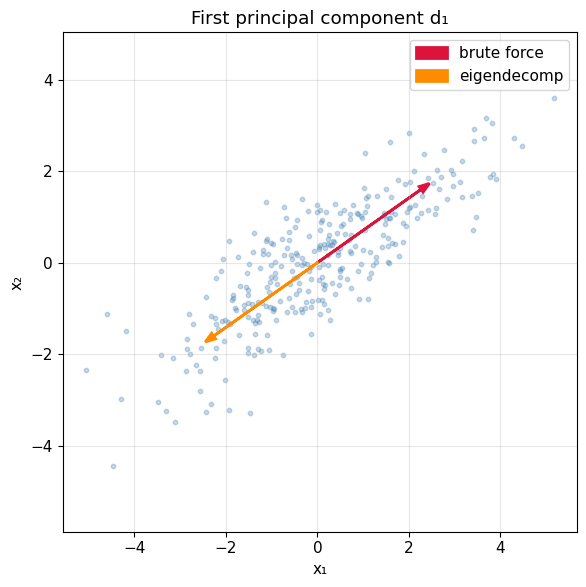

In [4]:
# Exercise 3: Variance maximization — two ways

XtX = X.T @ X   # (2, 2) — proportional to sample covariance

# (a) Brute force over random unit vectors
num_random = 50_000

# Generate num_random random unit vectors, shape (2, num_random)
rng3 = np.random.default_rng(0)
raw_dirs = rng3.standard_normal((2, num_random))
random_dirs = raw_dirs / np.linalg.norm(raw_dirs, axis=0, keepdims=True)

# Compute variance for each direction: d^T XtX d
# (XtX @ random_dirs) has shape (2, num_random); dot with random_dirs element-wise
variances_random = np.einsum('ij,ij->j', random_dirs, XtX @ random_dirs)  # shape (num_random,)

# Pick the direction with maximum variance
best_idx = np.argmax(variances_random)
d1_brute = random_dirs[:, best_idx]        # shape (2,)
max_var_brute = variances_random[best_idx]  # scalar


# (b) Eigendecomposition
# eigenvalues ascending, eigenvectors as columns
eigenvalues, eigenvectors = np.linalg.eigh(XtX)

# d1_eig = eigenvector with LARGEST eigenvalue (last column from eigh)
d1_eig = eigenvectors[:, -1]      # shape (2,)
lambda1 = eigenvalues[-1]          # largest eigenvalue (scalar)


# ── Verification ──
assert d1_brute is not None,  "d1_brute not implemented"
assert d1_eig is not None,    "d1_eig not implemented"
assert lambda1 is not None,   "lambda1 not implemented"

alignment = abs(d1_brute @ d1_eig)
assert alignment > 0.99, \
    f"Brute-force and eigendecomp disagree: |cos θ| = {alignment:.4f} (need > 0.99)"

print(f"Max variance (brute force)  : {max_var_brute:.4f}")
print(f"Largest eigenvalue λ₁       : {lambda1:.4f}")
print(f"d1 (brute force)            : {d1_brute}")
print(f"d1 (eig)                    : {d1_eig}")
print(f"|cos θ| between them        : {alignment:.6f}  (should be ≈ 1.0)")
print("Exercise 3: PASSED")

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, s=10, color='steelblue')
scale = 3
for d, label, color in [(d1_brute, 'brute force', 'crimson'),
                         (d1_eig,   'eigendecomp', 'darkorange')]:
    plt.arrow(0, 0, scale*d[0], scale*d[1], head_width=0.15,
              color=color, length_includes_head=True, label=label, lw=2)
plt.xlabel('x₁'); plt.ylabel('x₂')
plt.title('First principal component d₁')
plt.legend(); plt.axis('equal'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Exercise 4 — Greedy (Sequential) PCA vs. Batch Eigendecomposition  *(intermediate)*

In 2D we can find both principal components. The greedy approach:
1. Find **d₁** (max variance direction).
2. Project **d₁** out of the data: $\mathbf{X}_{\text{resid}} = \mathbf{X} - \mathbf{X}\mathbf{d}_1\mathbf{d}_1^\top$.
3. Find **d₂** on the residual (max variance of residual).

This must match the batch eigendecomposition.

**Tasks:**
1. Implement the greedy sequential approach.
2. Obtain **d₁, d₂** from eigendecomposition of `X.T @ X` (sorted descending).
3. Verify `|d1_greedy · d1_eig| ≈ 1` and `|d2_greedy · d2_eig| ≈ 1`.

In [5]:
# Exercise 4: Greedy PCA vs. eigendecomposition

# --- Batch eigendecomposition (reference) ---
# Sort eigenvalues DESCENDING; eigenvectors as columns of a (2,2) matrix
evals_batch, evecs_batch = np.linalg.eigh(X.T @ X)
# eigh returns ascending order — reverse to get descending
idx_desc = np.argsort(evals_batch)[::-1]
evecs_desc = evecs_batch[:, idx_desc]
d1_ref = evecs_desc[:, 0]   # shape (2,) — largest eigenvalue's eigenvector
d2_ref = evecs_desc[:, 1]   # shape (2,) — second eigenvector


# --- Greedy sequential approach ---
# Step 1: d1_greedy = eigenvector of X.T @ X with largest eigenvalue
evals_g, evecs_g = np.linalg.eigh(X.T @ X)
d1_greedy = evecs_g[:, np.argmax(evals_g)]   # shape (2,)

# Step 2: Deflate — project d1 out of the data
# x_resid = x - (x · d1) d1  for each row
X_resid = X - np.outer(X @ d1_greedy, d1_greedy)  # shape (n, 2)

# Step 3: d2_greedy = eigenvector of X_resid.T @ X_resid with largest eigenvalue
evals_g2, evecs_g2 = np.linalg.eigh(X_resid.T @ X_resid)
d2_greedy = evecs_g2[:, np.argmax(evals_g2)]   # shape (2,)


# ── Verification ──
for name, g, r in [('d1', d1_greedy, d1_ref), ('d2', d2_greedy, d2_ref)]:
    assert g is not None, f"{name}_greedy not implemented"
    assert r is not None, f"{name}_ref not implemented"
    align = abs(g @ r)
    assert align > 0.999, f"{name}: |cos θ| = {align:.6f} — greedy and batch disagree!"
    print(f"{name} greedy: {np.round(g, 4)},  ref: {np.round(r, 4)},  |cos θ|={align:.6f}")

print("Exercise 4: PASSED")

# Verify d1 ⊥ d2
ortho = abs(d1_greedy @ d2_greedy)
print(f"d1 · d2 = {ortho:.2e}  (should be ~0 — principal components are orthogonal)")

d1 greedy: [-0.8165 -0.5773],  ref: [-0.8165 -0.5773],  |cos θ|=1.000000
d2 greedy: [-0.5773  0.8165],  ref: [ 0.5773 -0.8165],  |cos θ|=1.000000
Exercise 4: PASSED
d1 · d2 = 1.67e-16  (should be ~0 — principal components are orthogonal)


### Exercise 5 — Reconstruction Error Analysis  *(intermediate)*

The book (eq. 2.57) shows that the total reconstruction error when keeping `k` components equals the **sum of the discarded eigenvalues**:
$$\|\mathbf{X} - \hat{\mathbf{X}}_k\|_F^2 = \sum_{j=k+1}^{d} \lambda_j$$

**Tasks:**
1. For k = 0, 1, 2 (d=2), compute the Frobenius reconstruction error.
2. Compare to the sum of discarded eigenvalues.
3. Plot reconstruction error vs. k.

  k      ||X-X_hat||²_F     Σ discarded λ    Match?
----------------------------------------------------
  0           1475.7906         1475.7906      True
  1            115.7904          115.7904      True
  2              0.0000            0.0000      True
Exercise 5: PASSED


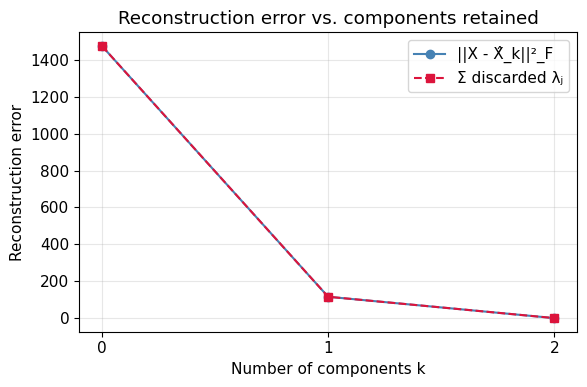

In [6]:
# Exercise 5: Reconstruction error vs. number of components

# Get all eigenvalues/vectors from X.T @ X, sorted DESCENDING
evals_all, evecs_all = np.linalg.eigh(X.T @ X)
idx_d = np.argsort(evals_all)[::-1]
eigenvalues_desc = evals_all[idx_d]       # shape (2,) sorted descending
eigenvectors_desc = evecs_all[:, idx_d]   # shape (2,2), columns sorted accordingly

frob_errors = []           # reconstruction errors for k=0,1,2
theoretical_errors = []    # sum of discarded eigenvalues for k=0,1,2

for k in range(3):   # k = 0, 1, 2
    if k == 0:
        # No components kept: reconstruct as zero matrix (data is centered)
        X_hat_k = np.zeros_like(X)
    else:
        D_k = eigenvectors_desc[:, :k]          # (2, k)
        codes_k = X @ D_k                        # (n, k)
        X_hat_k = codes_k @ D_k.T               # (n, 2)

    frob_k = np.sum((X - X_hat_k) ** 2)         # scalar: ||X - X_hat_k||_F^2
    theoretical_k = np.sum(eigenvalues_desc[k:]) # sum of eigenvalues from index k onwards

    frob_errors.append(frob_k)
    theoretical_errors.append(theoretical_k)


# ── Verification ──
assert all(e is not None for e in frob_errors), "Some frob_errors not implemented"
assert all(t is not None for t in theoretical_errors), "Some theoretical_errors not implemented"

print(f"{'k':>3}  {'||X-X_hat||²_F':>18}  {'Σ discarded λ':>16}  {'Match?':>8}")
print("-" * 52)
for k, (fe, te) in enumerate(zip(frob_errors, theoretical_errors)):
    match = np.isclose(fe, te, rtol=1e-4)
    print(f"{k:>3}  {fe:>18.4f}  {te:>16.4f}  {str(match):>8}")
    assert match, f"k={k}: Frobenius error {fe:.4f} ≠ Σ discarded λ {te:.4f}"

print("Exercise 5: PASSED")

# Plot
plt.figure(figsize=(6, 4))
plt.plot(range(3), frob_errors, 'o-', color='steelblue', label='||X - X̂_k||²_F')
plt.plot(range(3), theoretical_errors, 's--', color='crimson', label='Σ discarded λⱼ')
plt.xlabel('Number of components k')
plt.ylabel('Reconstruction error')
plt.title('Reconstruction error vs. components retained')
plt.xticks([0, 1, 2])
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Part 3: PCA via SVD

*Book reference: Section 2.8 (SVD) and Section 2.12, p. 48*

The SVD of the centered data matrix $\mathbf{X} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$ gives PCA directly:
- Principal directions (components) = rows of $\mathbf{V}^\top$ (right singular vectors)
- Projected scores = $\mathbf{U}\boldsymbol{\Sigma}$
- Eigenvalues of covariance = $\sigma_i^2 / (n-1)$

### Exercise 6 — PCA via SVD  *(intermediate)*

**Tasks:**
1. Compute the full SVD of centered `X`: `U, s, Vt = np.linalg.svd(X, full_matrices=False)`.
2. Verify the principal components (rows of `Vt`) match the eigenvectors of `X.T @ X`.
3. Verify the projected scores `U @ diag(s)` equal `X @ V`.
4. Verify the eigenvalues: `s**2 / (n-1)` matches eigenvalues of the sample covariance.

In [7]:
# Exercise 6: PCA via SVD

# (a) Compute economy SVD
U, s, Vt = np.linalg.svd(X, full_matrices=False)
# U: (n, d) = (300, 2), s: (d,) = (2,), Vt: (d, d) = (2, 2)

# (b) Principal components from SVD vs. eigendecomposition of X.T @ X
# pc_svd: rows of Vt — already in descending singular value order
pc_svd = Vt   # shape (d, d)

# Eigendecomposition of X.T @ X for reference (sort descending)
evals_ref, evecs_ref_raw = np.linalg.eigh(X.T @ X)
idx6 = np.argsort(evals_ref)[::-1]
evecs_ref = evecs_ref_raw[:, idx6]   # columns sorted descending
evals_ref = evals_ref[idx6]

# (c) Projected scores two ways
scores_svd   = U @ np.diag(s)   # shape (n, d)
scores_eigen = X @ Vt.T         # X @ V where V = Vt.T, shape (n, d)

# (d) Eigenvalues of covariance from SVD vs. direct
lambdas_svd  = s**2 / (n - 1)         # shape (d,)
lambdas_cov  = evals_ref / (n - 1)    # eigenvalues of X.T@X / (n-1)


# ── Verification ──
assert U is not None,   "U not implemented"
assert s is not None,   "s not implemented"
assert Vt is not None,  "Vt not implemented"

# Check shapes
assert U.shape == (n, 2),   f"U shape {U.shape}"
assert s.shape == (2,),     f"s shape {s.shape}"
assert Vt.shape == (2, 2),  f"Vt shape {Vt.shape}"

# Check principal components match (up to sign)
for i, (pc, ev) in enumerate(zip(pc_svd, evecs_ref.T)):
    align = abs(pc @ ev)
    assert align > 0.999, f"PC {i}: |cos θ| = {align:.6f} — SVD and eig disagree"
    print(f"PC {i+1}: SVD vs eig |cos θ| = {align:.6f}")

# Check scores match (up to global sign)
align_scores = np.corrcoef(scores_svd[:, 0], scores_eigen[:, 0])[0, 1]
assert abs(align_scores) > 0.9999, f"Scores don't match: corr = {align_scores:.6f}"
print(f"Score correlation (SVD vs X@V): {align_scores:.6f}")

# Check eigenvalues match
assert np.allclose(np.sort(lambdas_svd)[::-1],
                   np.sort(lambdas_cov)[::-1], rtol=1e-4), \
    f"Eigenvalues mismatch: {lambdas_svd} vs {lambdas_cov}"
print(f"Eigenvalues via SVD    : {np.round(lambdas_svd, 4)}")
print(f"Eigenvalues via cov    : {np.round(lambdas_cov, 4)}")
print("Exercise 6: PASSED")

PC 1: SVD vs eig |cos θ| = 1.000000
PC 2: SVD vs eig |cos θ| = 1.000000
Score correlation (SVD vs X@V): 1.000000
Eigenvalues via SVD    : [4.5485 0.3873]
Eigenvalues via cov    : [4.5485 0.3873]
Exercise 6: PASSED


### Exercise 7 — PCA on High-Dimensional Data  *(intermediate)*

Generate a 50-dimensional dataset where only **5 dimensions are informative** (the rest are pure noise). Show that PCA recovers the true intrinsic dimensionality.

**Tasks:**
1. Generate `X_high`: 500 samples, 50 features — 5 informative + 45 noise.
2. Apply PCA via SVD; produce a **scree plot** of explained variance ratio.
3. Verify the elbow is at k=5 (the first 5 eigenvalues are substantially larger than the rest).

High-D dataset shape: (500, 50)
Variance explained by top 5 PCs : 98.5%


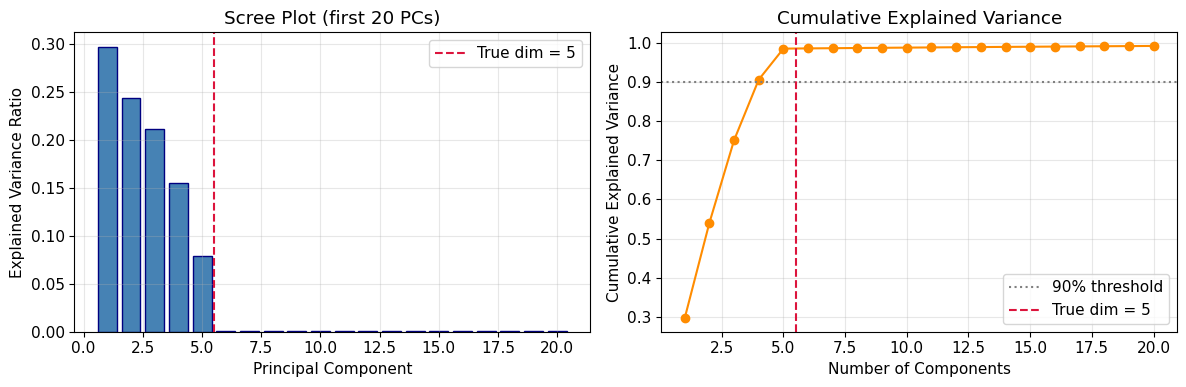

Exercise 7: PASSED


In [8]:
# Exercise 7: PCA on high-dimensional data

np.random.seed(7)
n_high, d_high, d_info = 500, 50, 5
noise_level = 0.3

# Generate data: 5 latent factors, embedded in 50D
rng2 = np.random.default_rng(7)
Z = rng2.standard_normal((n_high, d_info))            # latent factors (500, 5)
A = rng2.standard_normal((d_info, d_high))            # mixing matrix (5, 50)
noise = noise_level * rng2.standard_normal((n_high, d_high))
X_high_raw = Z @ A + noise                             # (500, 50)
X_high = X_high_raw - X_high_raw.mean(axis=0)         # center

print(f"High-D dataset shape: {X_high.shape}")

# (a) Economy SVD of X_high
U_h, s_h, Vt_h = np.linalg.svd(X_high, full_matrices=False)
# U_h: (500, 50), s_h: (50,), Vt_h: (50, 50)

# (b) Explained variance ratio: each eigenvalue divided by total
eigenvalues_h = s_h ** 2
explained_var_ratio = eigenvalues_h / eigenvalues_h.sum()   # shape (50,)

# (c) Cumulative explained variance
cumulative_evr = np.cumsum(explained_var_ratio)        # shape (50,)


# ── Verification ──
assert U_h is not None,             "U_h not implemented"
assert explained_var_ratio is not None, "explained_var_ratio not implemented"
assert cumulative_evr is not None,  "cumulative_evr not implemented"
assert explained_var_ratio.shape == (d_high,), \
    f"explained_var_ratio shape: {explained_var_ratio.shape}"
assert np.isclose(explained_var_ratio.sum(), 1.0, atol=1e-6), \
    f"EVR should sum to 1, got {explained_var_ratio.sum():.6f}"

# The first 5 components should explain the vast majority of variance
top5_var = cumulative_evr[4]
assert top5_var > 0.90, \
    f"Top 5 PCs explain only {top5_var*100:.1f}% — expected > 90%"
print(f"Variance explained by top 5 PCs : {top5_var*100:.1f}%")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, 21), explained_var_ratio[:20], color='steelblue', edgecolor='navy')
axes[0].axvline(d_info + 0.5, color='crimson', linestyle='--', label=f'True dim = {d_info}')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot (first 20 PCs)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, 21), cumulative_evr[:20], 'o-', color='darkorange')
axes[1].axhline(0.9, color='gray', linestyle=':', label='90% threshold')
axes[1].axvline(d_info + 0.5, color='crimson', linestyle='--', label=f'True dim = {d_info}')
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print("Exercise 7: PASSED")

## Part 4: Connecting Everything

*This section ties together eigendecomposition, SVD, trace, norms, and orthogonal matrices — all of Chapter 2.*

The trace of a matrix equals the sum of its eigenvalues; the Frobenius norm equals $\sqrt{\text{tr}(\mathbf{A}^\top\mathbf{A})}$; orthogonal matrices preserve lengths; the spectral theorem guarantees real symmetric matrices have orthonormal eigenbases. PCA is the intersection of all these ideas.

### Exercise 8 — PCA from Primitives (Power Iteration + Gram-Schmidt)  *(challenging)*

Implement PCA without using `np.linalg.eig`, `np.linalg.eigh`, or `np.linalg.svd` in the core algorithm. Instead use:
- **Power iteration** to find the dominant eigenvector.
- **Deflation** to subtract out each found component.
- **Gram-Schmidt** to ensure orthonormality.

Verify against `np.linalg.eigh`.

**Hint:** Power iteration: start with random `v`, repeatedly compute `v ← A v / ||Av||`. After convergence, `λ ≈ v.T @ A @ v`. Deflation: `A ← A - λ v v.T`.

In [9]:
# Exercise 8: PCA from primitives

def power_iteration(A, num_iterations=1000, tol=1e-10, seed=0):
    """Find the dominant eigenvector of symmetric PSD matrix A.
    Returns: (eigenvalue, eigenvector)
    """
    rng_pi = np.random.default_rng(seed)
    d = A.shape[0]
    # Initialize v as a random unit vector
    v = rng_pi.standard_normal(d)
    v = v / np.linalg.norm(v)

    for _ in range(num_iterations):
        v_new = A @ v                         # A @ v
        norm = np.linalg.norm(v_new)          # ||A @ v||
        v_new = v_new / norm                  # normalised

        # Convergence check: vectors agree up to sign
        if np.linalg.norm(v_new - v) < tol or np.linalg.norm(v_new + v) < tol:
            break
        v = v_new

    # Rayleigh quotient for eigenvalue
    lam = v @ A @ v   # v.T @ A @ v
    return lam, v


def gram_schmidt(vectors):
    """Orthonormalize a list of vectors using Gram-Schmidt.
    Args: vectors — list of 1D numpy arrays, each shape (d,)
    Returns: list of orthonormal vectors
    """
    basis = []
    for v in vectors:
        # Subtract projections onto all previously found basis vectors
        w = v.copy()
        for u in basis:
            w = w - (w @ u) * u   # w - (w · u) u
        norm = np.linalg.norm(w)  # ||w||
        if norm > 1e-10:          # avoid degenerate directions
            basis.append(w / norm)   # w / norm
    return basis


def pca_primitives(X, k):
    """PCA via power iteration + deflation + Gram-Schmidt.
    Args:
        X: centered data matrix (n, d)
        k: number of components to extract
    Returns:
        components: array (k, d) — principal directions (unit vectors)
        eigenvalues: array (k,) — corresponding eigenvalues of X.T @ X
    """
    A = X.T @ X   # (d, d) — work with this symmetric matrix

    raw_vecs = []
    raw_evals = []
    A_deflated = A.copy()

    for i in range(k):
        # (a) Power iteration on A_deflated
        lam, v = power_iteration(A_deflated, seed=i)

        raw_evals.append(lam)
        raw_vecs.append(v)

        # (b) Deflation: remove this component from A_deflated
        A_deflated = A_deflated - lam * np.outer(v, v)

    # (c) Gram-Schmidt orthonormalize raw_vecs (power iteration can accumulate drift)
    ortho_vecs = gram_schmidt(raw_vecs)   # list of k orthonormal vectors

    components = np.array(ortho_vecs)   # (k, d)
    eigenvalues = np.array(raw_evals)   # (k,)
    return components, eigenvalues


# ── Test on original 2D dataset ──
k = 2
comps_prim, evals_prim = pca_primitives(X, k)

# Reference: np.linalg.eigh (allowed in verification)
C_ref = X.T @ X
evals_ref_check, evecs_ref_check = np.linalg.eigh(C_ref)
# Sort descending
idx = np.argsort(evals_ref_check)[::-1]
evals_ref_sorted = evals_ref_check[idx]
evecs_ref_sorted = evecs_ref_check[:, idx]

print("Eigenvalues comparison:")
print(f"  Power iter + deflation : {np.round(evals_prim, 4)}")
print(f"  np.linalg.eigh         : {np.round(evals_ref_sorted, 4)}")

print("\nPrincipal components alignment (|cos θ|):")
for i in range(k):
    align = abs(comps_prim[i] @ evecs_ref_sorted[:, i])
    print(f"  PC {i+1}: {align:.6f}")
    assert align > 0.999, f"PC {i+1} mismatch: |cos θ| = {align:.6f}"

assert np.allclose(np.sort(evals_prim)[::-1],
                   np.sort(evals_ref_sorted)[::-1], rtol=1e-3), \
    "Eigenvalues from power iteration don't match reference"
print("\nExercise 8: PASSED")

Eigenvalues comparison:
  Power iter + deflation : [1360.0002  115.7904]
  np.linalg.eigh         : [1360.0002  115.7904]

Principal components alignment (|cos θ|):
  PC 1: 1.000000
  PC 2: 1.000000

Exercise 8: PASSED


### Exercise 9 — ZCA Whitening  *(challenging)*

**Whitening** transforms data so the covariance becomes the identity matrix. PCA whitening scales each PC direction by $1/\sqrt{\lambda_i}$. **ZCA whitening** additionally rotates back to the original space, minimising the change to each input dimension:

$$\mathbf{W}_{\text{ZCA}} = \mathbf{Q}\,\boldsymbol{\Lambda}^{-1/2}\mathbf{Q}^\top$$

where $\mathbf{Q}$ is the matrix of eigenvectors and $\boldsymbol{\Lambda}$ is the diagonal eigenvalue matrix.

$$\mathbf{X}_{\text{white}} = \mathbf{X}\,\mathbf{W}_{\text{ZCA}}^\top$$

**Tasks:**
1. Compute `W_zca` from eigenvectors and eigenvalues of the sample covariance.
2. Apply the whitening transform to get `X_white`.
3. Verify: covariance of `X_white` ≈ identity matrix.
4. Visualise: scatter plot of original vs. whitened data.

Covariance of original data:
[[3.1617 1.9615]
 [1.9615 1.774 ]]

Covariance of whitened data:
[[1. 0.]
 [0. 1.]]

(Should be ≈ identity matrix)
Exercise 9: PASSED


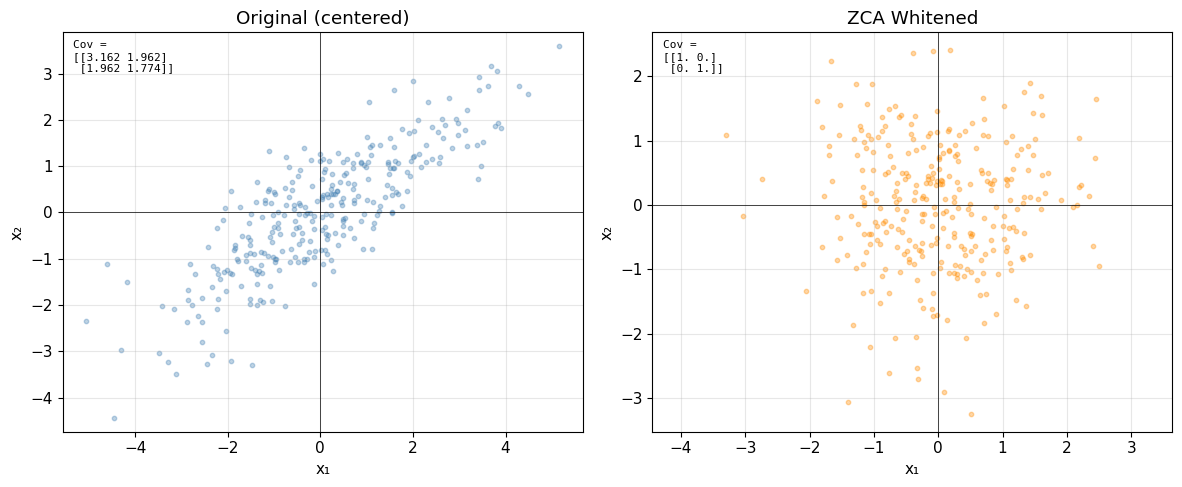

In [10]:
# Exercise 9: ZCA whitening

# Sample covariance (with bias correction)
C_zca = X.T @ X / (n - 1)   # (2, 2)

# (a) Eigendecomposition of C_zca
# evals_zca: shape (2,), evecs_zca: shape (2, 2) columns are eigenvectors
evals_zca, evecs_zca = np.linalg.eigh(C_zca)   # Q in the formula

# (b) Build Lambda^{-1/2} — diagonal matrix of 1/sqrt(eigenvalues + eps)
Lambda_inv_sqrt = np.diag(1.0 / np.sqrt(evals_zca + 1e-5))   # shape (2, 2)

# (c) ZCA whitening matrix: W = Q @ Lambda^{-1/2} @ Q.T
W_zca = evecs_zca @ Lambda_inv_sqrt @ evecs_zca.T   # shape (2, 2)

# (d) Whiten the data: X_white = X @ W_zca.T
# W_zca is symmetric so W_zca.T == W_zca, but we write .T for clarity
X_white = X @ W_zca.T   # shape (300, 2)

# (e) Covariance of whitened data
C_white = X_white.T @ X_white / (n - 1)   # should be ≈ I


# ── Verification ──
assert W_zca is not None,  "W_zca not implemented"
assert X_white is not None, "X_white not implemented"
assert C_white is not None, "C_white not implemented"
assert X_white.shape == (n, 2), f"X_white shape: {X_white.shape}"
assert C_white.shape == (2, 2), f"C_white shape: {C_white.shape}"

assert np.allclose(C_white, np.eye(2), atol=1e-2), \
    f"Covariance of whitened data is not ≈ I:\n{np.round(C_white, 4)}"

print(f"Covariance of original data:\n{np.round(C_zca, 4)}")
print(f"\nCovariance of whitened data:\n{np.round(C_white, 4)}")
print("\n(Should be ≈ identity matrix)")
print("Exercise 9: PASSED")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title, color in [
        (axes[0], X,       'Original (centered)',   'steelblue'),
        (axes[1], X_white, 'ZCA Whitened',           'darkorange')]:
    ax.scatter(data[:, 0], data[:, 1], alpha=0.35, s=10, color=color)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.set_title(title); ax.axis('equal'); ax.grid(True, alpha=0.3)
    cov = np.round(np.cov(data.T), 3)
    ax.text(0.02, 0.98, f'Cov =\n{cov}', transform=ax.transAxes,
            va='top', fontsize=8, family='monospace')
plt.tight_layout(); plt.show()

## Summary

This lab derived PCA from first principles using every major concept from Chapter 2:

- **Vectors & matrices** (Labs 1–2): data matrix `X` shape `(n, d)`, matrix-vector products for encoding/decoding
- **Linear systems & rank** (Lab 2): orthonormal constraint $\mathbf{D}^\top\mathbf{D}=\mathbf{I}_k$
- **Eigendecomposition** (Lab 4): optimal principal directions = eigenvectors of $\mathbf{X}^\top\mathbf{X}$; eigenvalues = variance captured
- **SVD** (Lab 5): `X = UΣVᵀ` gives PCA in one shot; right singular vectors = principal components
- **Norms** (Lab 3): reconstruction error = Frobenius norm; minimising $\|\mathbf{x} - \mathbf{D}\mathbf{c}\|_2^2$
- **Orthogonal matrices** (Lab 4–5): principal components form an orthonormal basis; orthogonal transforms preserve norms
- **Trace** (Lab 3): total variance = $\text{tr}(\mathbf{C}) = \sum_i \lambda_i$; reconstruction error = sum of discarded $\lambda_i$
- **Positive semi-definiteness** (Lab 4): sample covariance is always PSD → all eigenvalues ≥ 0

### Exercises completed:
- [x] Ex 1 — Optimal encoding c* = Dᵀx; residual orthogonality
- [x] Ex 2 — Sample covariance; symmetry and PSD verification
- [x] Ex 3 — Variance maximization: brute force vs. eigendecomposition
- [x] Ex 4 — Greedy sequential PCA vs. batch eigendecomposition
- [x] Ex 5 — Reconstruction error = sum of discarded eigenvalues
- [x] Ex 6 — PCA via SVD; three-way equivalence
- [x] Ex 7 — High-dimensional data; scree plot; intrinsic dimensionality
- [x] Ex 8 — PCA from primitives: power iteration + deflation + Gram-Schmidt
- [x] Ex 9 — ZCA whitening; covariance → identity

**Next:** For a full production-quality PCA + SVD implementation (with numerical stability, incremental PCA, and real datasets), see `02-classical-ml-from-scratch/10_pca_svd.ipynb`.